# Training-Exact Connectome Priors Audit

This notebook pulls the exact Cook2019 + c302 pathway samples used by `generate_ncap_segment_priors(...)` and visualizes:
- synapse types/counts/distances used in training priors
- average synapse count and average distance per pathway
- per-pathway distributions for synapse count and distance
- a motor-circuit network plot (edge width = synapse strength, edge color = distance) with node jitter


In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd

repo_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'NMAP').is_dir()), None)
if repo_root is None:
    raise FileNotFoundError('Could not locate repository root containing NMAP/')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from NMAP.connectome_priors.notebook_training_priors import (
    PATHWAY_COLORS,
    PATHWAY_ORDER,
    PATHWAY_SOURCES,
    collect_training_pathway_tables,
    cook_positions_for_nodes,
    node_class,
    node_class_colors,
    top_edges_by_pathway,
)

order = list(PATHWAY_ORDER)
palette = [PATHWAY_COLORS[p] for p in order]


In [8]:
TABLES = collect_training_pathway_tables(num_segments=8)
samples_df = TABLES['samples']
summary_df = TABLES['summary'].set_index('pathway').loc[order].reset_index()
priors = TABLES['priors']

print('Training source metadata:')
print(priors.get('sources', {}))

n_pathways = len(order)
print(f'\nNumber of connectome priors/pathways used by training: {n_pathways}')
print('Pathways:', order)
if n_pathways != 6:
    print('WARNING: pathway count is not 6; plots will reflect the actual count above.')

display_cols = [
    'pathway',
    'source',
    'raw_edge_count_from_connectome',
    'used_edge_count_with_geometry',
    'syn_sum_from_samples',
    'syn_mean_from_samples',
    'dist_mean_um',
    'dist_median_um',
    'dist_std_um',
]

print('\nExact synapse types, counts, and distances used by training pathways:')
print(summary_df[display_cols].to_string(index=False))

print('\nSynapse-type totals across all used pathway samples:')
print(samples_df.groupby('source').size().rename('n_samples').to_string())


Training source metadata:
{'cook2019_adjacency_xlsx': '/home/amin/Research/NCAP/external/ConnectomeToolbox/cect/data/SI 5 Connectome adjacency matrices.xlsx', 'cook2019_chemical_sheet': 'hermaphrodite chemical', 'cook2019_gap_sheet': 'herm gap jn symmetric', 'c302_geometry_nml': '/home/amin/Research/NCAP/external/ConnectomeToolbox/cect/data/c302_C2_FW.net.nml', 'canonical_edge_list_csv': '/home/amin/Research/NCAP/external/ConnectomeToolbox/cect/data/herm_full_edgelist_MODIFIED.csv'}

Number of connectome priors/pathways used by training: 6
Pathways: ['ipsi_db', 'ipsi_vb', 'contra_db', 'contra_vb', 'next_db', 'next_vb']

Exact synapse types, counts, and distances used by training pathways:
  pathway       source  raw_edge_count_from_connectome  used_edge_count_with_geometry  syn_sum_from_samples  syn_mean_from_samples  dist_mean_um  dist_median_um  dist_std_um
  ipsi_db     chemical                              41                             41            310.000000               7.5609

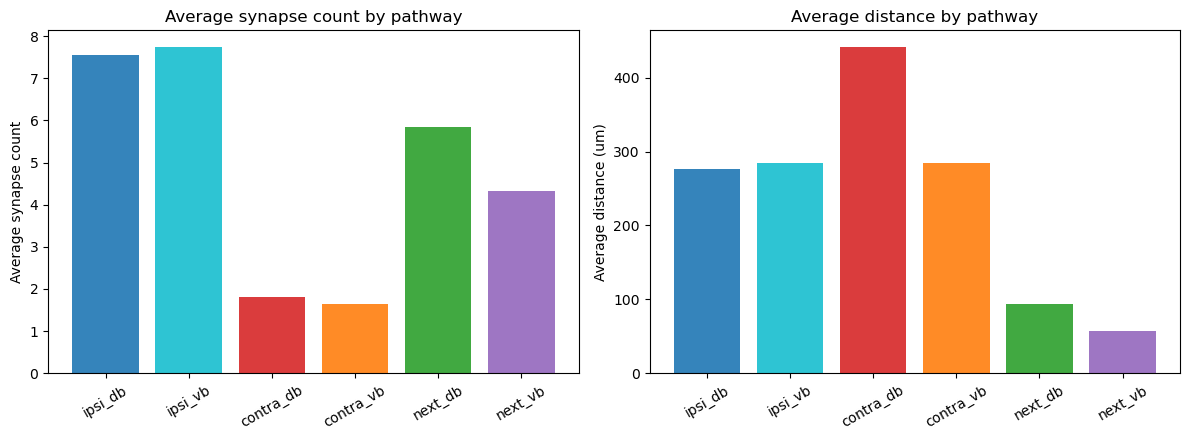

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_df = summary_df.set_index('pathway').loc[order].reset_index()
x = np.arange(len(order))

axes[0].bar(x, plot_df['syn_mean_from_samples'], color=palette, alpha=0.9)
axes[0].set_title('Average synapse count by pathway')
axes[0].set_ylabel('Average synapse count')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, rotation=30)

axes[1].bar(x, plot_df['dist_mean_um'], color=palette, alpha=0.9)
axes[1].set_title('Average distance by pathway')
axes[1].set_ylabel('Average distance (um)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(order, rotation=30)

plt.tight_layout()
plt.show()


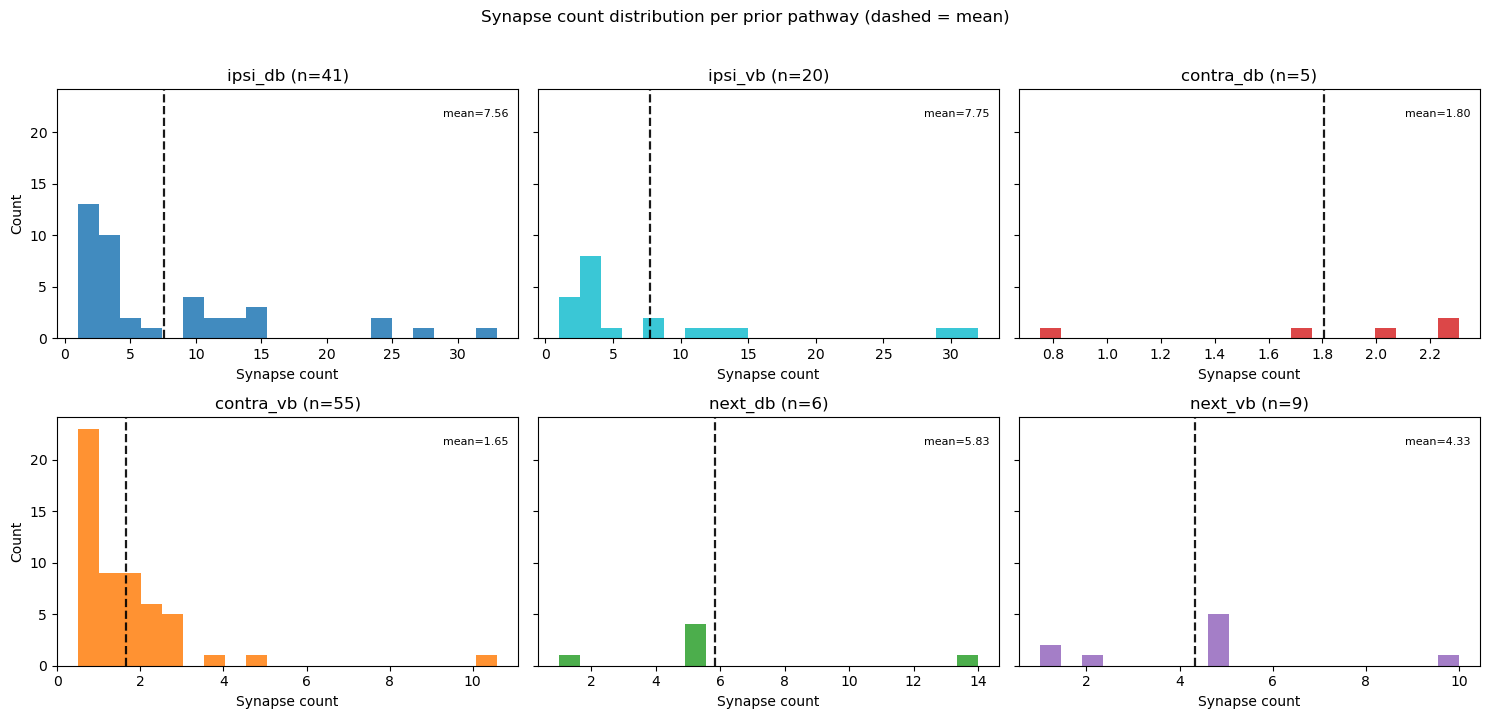

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, pathway in zip(axes.ravel(), order):
    sdf = samples_df[samples_df['pathway'] == pathway]
    syn_vals = sdf['syn'].to_numpy()
    if syn_vals.size == 0:
        ax.set_title(f'{pathway} (n=0)')
        continue
    ax.hist(syn_vals, bins=20, color=PATHWAY_COLORS[pathway], alpha=0.85)
    mean_syn = float(np.mean(syn_vals))
    ax.axvline(mean_syn, linestyle='--', color='black', linewidth=1.6, alpha=0.9)
    ax.set_title(f"{pathway} (n={syn_vals.size})")
    ax.set_xlabel('Synapse count')
    ax.text(0.98, 0.92, f"mean={mean_syn:.2f}", transform=ax.transAxes, ha='right', va='top', fontsize=8)
axes[0, 0].set_ylabel('Count')
axes[1, 0].set_ylabel('Count')
fig.suptitle('Synapse count distribution per prior pathway (dashed = mean)', y=1.02)
plt.tight_layout()
plt.show()


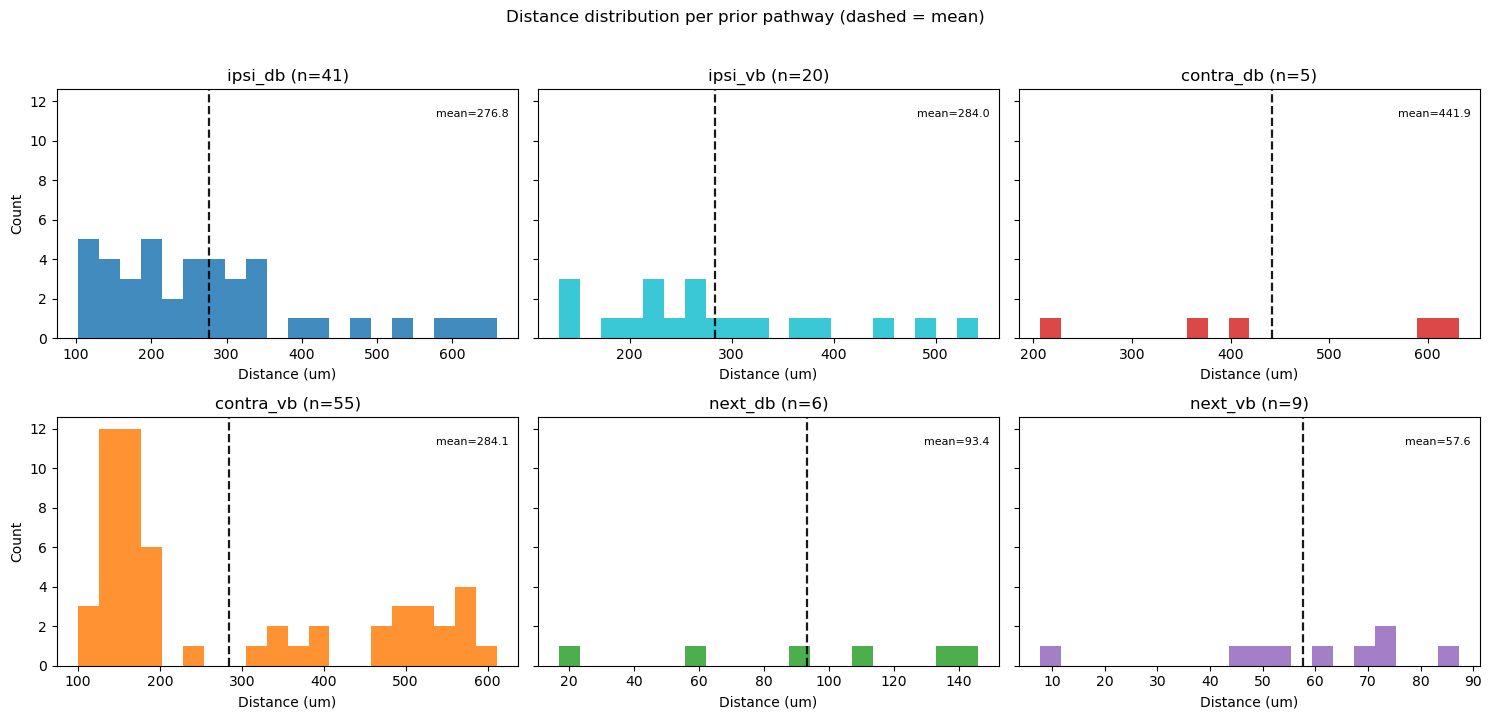

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, pathway in zip(axes.ravel(), order):
    sdf = samples_df[(samples_df['pathway'] == pathway) & np.isfinite(samples_df['dist_um'])]
    dist_vals = sdf['dist_um'].to_numpy()
    if dist_vals.size == 0:
        ax.set_title(f'{pathway} (n=0)')
        continue
    ax.hist(dist_vals, bins=20, color=PATHWAY_COLORS[pathway], alpha=0.85)
    mean_dist = float(np.mean(dist_vals))
    ax.axvline(mean_dist, linestyle='--', color='black', linewidth=1.6, alpha=0.9)
    ax.set_title(f"{pathway} (n={dist_vals.size})")
    ax.set_xlabel('Distance (um)')
    ax.text(0.98, 0.92, f"mean={mean_dist:.1f}", transform=ax.transAxes, ha='right', va='top', fontsize=8)
axes[0, 0].set_ylabel('Count')
axes[1, 0].set_ylabel('Count')
fig.suptitle('Distance distribution per prior pathway (dashed = mean)', y=1.02)
plt.tight_layout()
plt.show()


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

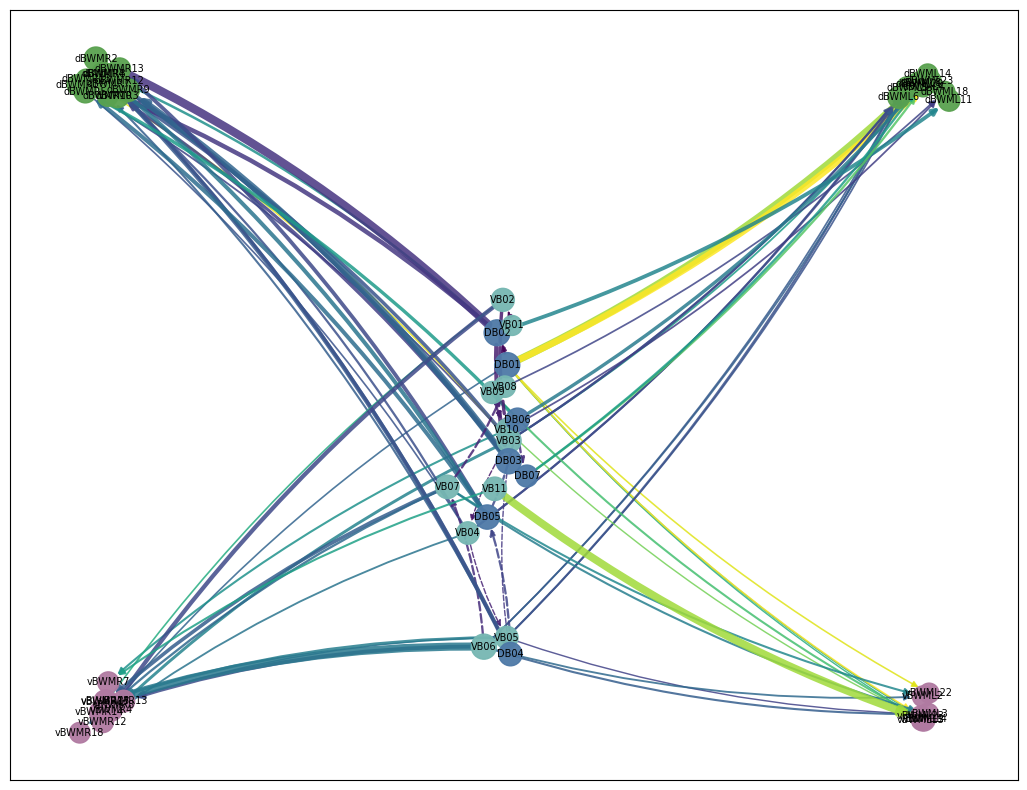

In [12]:
# Neuron-only network view (nodes used in training pathways)
neuron_classes = {'DB', 'VB', 'DD', 'VD'}

edge_df = top_edges_by_pathway(samples_df, top_k=12)
edge_df = edge_df[np.isfinite(edge_df['dist_um'])].copy()
edge_df['pre_cls'] = edge_df['pre'].map(node_class)
edge_df['post_cls'] = edge_df['post'].map(node_class)
edge_df = edge_df[
    edge_df['pre_cls'].isin(neuron_classes) & edge_df['post_cls'].isin(neuron_classes)
].copy()

edge_df = edge_df.groupby(['pathway', 'pre', 'post'], as_index=False).agg(
    syn=('syn', 'sum'),
    dist_um=('dist_um', 'mean'),
)

if edge_df.empty:
    raise RuntimeError('No neuron-only edges available for the network plot.')

G = nx.DiGraph()
for row in edge_df.itertuples(index=False):
    G.add_node(row.pre, cls=node_class(row.pre))
    G.add_node(row.post, cls=node_class(row.post))
    G.add_edge(row.pre, row.post, pathway=row.pathway, syn=float(row.syn), dist_um=float(row.dist_um))

node_palette = node_class_colors()

def node_index(name: str) -> int:
    digits = ''.join(ch for ch in str(name) if ch.isdigit())
    return int(digits) if digits else 0

# Structured layout by neuron class to avoid overlap, with slight jitter as requested.
class_x = {'DB': 0.0, 'DD': 1.0, 'VB': 2.0, 'VD': 3.0}
y_step = 1.8
rng = np.random.default_rng(7)

pos = {}
for cls in ['DB', 'DD', 'VB', 'VD']:
    cls_nodes = sorted([n for n in G.nodes() if node_class(n) == cls], key=node_index)
    if not cls_nodes:
        continue
    for i, n in enumerate(cls_nodes):
        y = -i * y_step
        jx, jy = rng.normal(0.0, 0.06, size=2)  # small jitter to avoid perfect stacking
        pos[n] = (class_x[cls] + jx, y + jy)

# Fallback for any unexpected class
for n in G.nodes():
    if n not in pos:
        pos[n] = tuple(rng.normal(0.0, 0.2, size=2))

edge_list = list(G.edges(data=True))
syn_vals = np.array([d['syn'] for _, _, d in edge_list], dtype=float)
dist_vals = np.array([d['dist_um'] for _, _, d in edge_list], dtype=float)

syn_min, syn_max = float(np.min(syn_vals)), float(np.max(syn_vals))
if syn_max - syn_min < 1e-12:
    edge_widths = [2.2 for _ in syn_vals]
else:
    edge_widths = [1.0 + 6.0 * ((s - syn_min) / (syn_max - syn_min)) for s in syn_vals]

dist_min, dist_max = float(np.min(dist_vals)), float(np.max(dist_vals))
if dist_max - dist_min < 1e-12:
    dist_max = dist_min + 1e-6
dist_norm = Normalize(vmin=dist_min, vmax=dist_max)
cmap = plt.cm.viridis
edge_colors = [cmap(dist_norm(d)) for d in dist_vals]

weighted_degree = {}
for n in G.nodes():
    out_w = sum(G[n][m]['syn'] for m in G.successors(n))
    in_w = sum(G[m][n]['syn'] for m in G.predecessors(n))
    weighted_degree[n] = in_w + out_w

node_sizes = [220 + 18 * np.sqrt(max(weighted_degree[n], 1e-8)) for n in G.nodes()]
node_colors = [node_palette.get(G.nodes[n].get('cls', 'other'), '#7f7f7f') for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 10))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.96, ax=ax)

for (u, v, d), width, color in zip(edge_list, edge_widths, edge_colors):
    style = '--' if PATHWAY_SOURCES[d['pathway']] == 'gap_junction' else '-'
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        width=width,
        edge_color=[color],
        style=style,
        alpha=0.82,
        arrows=True,
        arrowsize=10,
        connectionstyle='arc3,rad=0.08',
        ax=ax,
    )

nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

sm = ScalarMappable(norm=dist_norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Edge distance (um)')

node_legend = [
    mpatches.Patch(color=node_palette[cls], label=cls)
    for cls in ['DB', 'DD', 'VB', 'VD'] if cls in {node_class(n) for n in G.nodes()}
]
line_legend = [
    Line2D([0], [0], color='black', lw=2.4, linestyle='-', label='chemical pathway edge'),
    Line2D([0], [0], color='black', lw=2.4, linestyle='--', label='gap-junction pathway edge'),
]
legend1 = ax.legend(handles=node_legend, title='Neuron class', loc='upper left', bbox_to_anchor=(1.02, 1.0))
ax.add_artist(legend1)
ax.legend(handles=line_legend, title='Edge type', loc='upper left', bbox_to_anchor=(1.02, 0.62))

ax.set_title('Neuron-only motor prior network (width = synapse strength, color = distance)')
ax.axis('off')
fig.tight_layout()
plt.show()

print('Neuron-only edges shown in network plot:')
print(edge_df.sort_values('syn', ascending=False).to_string(index=False))
